# 2D Try-On Experiments

Run the current lightweight system end to end on a local image: face analysis, segmentation, recommendation, and a few try-on renders.

In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import display
from PIL import Image
import matplotlib.pyplot as plt

def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'backend').exists() and (candidate / 'notebooks').exists():
            return candidate
    raise RuntimeError('Could not locate project root.')

PROJECT_ROOT = find_project_root()
BACKEND_ROOT = PROJECT_ROOT / 'backend'
if str(BACKEND_ROOT) not in sys.path:
    sys.path.append(str(BACKEND_ROOT))

from app.core.asset_bank import asset_bank_summary, get_asset_by_id
from app.core.face_analyzer import analyze_face_image
from app.core.hair_segmentation import predict_hair_mask_image, save_predicted_hair_mask
from app.core.recommender import recommend_hairstyles
from app.core.tryon_2d_mediapipe_engine import render_mediapipe_static_tryon
from app.core.tryon_2d_engine import render_static_tryon
from app.models.schemas import FaceAttributes, RecommendationPreferences

PROJECT_ROOT

WindowsPath('D:/Projects/Personal Projects/Hairstyle Recommender Live Tryon')

In [2]:
import importlib
import app.core.tryon_2d_engine as tryon_2d_engine
import app.core.tryon_2d_mediapipe_engine as tryon_2d_mediapipe_engine

importlib.reload(tryon_2d_engine)
importlib.reload(tryon_2d_mediapipe_engine)
from app.core.tryon_2d_engine import render_static_tryon, render_static_tryon_image
from app.core.tryon_2d_mediapipe_engine import render_mediapipe_static_tryon, render_mediapipe_static_tryon_image

print("Default renderer:", render_static_tryon.__name__)
print("Experimental renderer:", render_mediapipe_static_tryon.__name__)

Default renderer: render_legacy_static_tryon
Experimental renderer: render_mediapipe_static_tryon


In [3]:
INPUT_IMAGE_PATH = PROJECT_ROOT / 'backend' / 'outputs' / 'uploads' / 'image2.jpg'
TARGET_GENDER = 'male'
TOP_K = 5
TRYON_TOP_K = 3

INPUT_IMAGE_PATH

WindowsPath('D:/Projects/Personal Projects/Hairstyle Recommender Live Tryon/backend/outputs/uploads/image2.jpg')

In [4]:
bank = asset_bank_summary()
print('Active asset bank:', bank['metadata_dir'])
print('Asset count:', bank['asset_count'])
bank

Active asset bank: D:\Projects\Personal Projects\Hairstyle Recommender Live Tryon\backend\data\processed\celeba_full_hair_assets\reviewed_render_safe\kept_assets.jsonl
Asset count: 83


{'asset_count': 83,
 'metadata_dir': 'D:\\Projects\\Personal Projects\\Hairstyle Recommender Live Tryon\\backend\\data\\processed\\celeba_full_hair_assets\\reviewed_render_safe\\kept_assets.jsonl'}

In [5]:
if not INPUT_IMAGE_PATH.exists():
    raise FileNotFoundError(f'Image not found: {INPUT_IMAGE_PATH}')

analysis = analyze_face_image(INPUT_IMAGE_PATH)
print('Face detected:', analysis.face_detected)
print('Message:', analysis.message)
analysis.geometry, analysis.face_attributes

Face detected: True
Message: Face landmarks detected successfully.


({'face_width_px': 156.46,
  'face_height_px': 181.61,
  'forehead_width_px': 154.63,
  'cheekbone_width_px': 154.12,
  'jaw_width_px': 131.39,
  'chin_width_px': 84.98,
  'aspect_ratio': 1.1607,
  'forehead_to_jaw_ratio': 1.1769,
  'cheekbone_to_jaw_ratio': 1.173,
  'chin_to_jaw_ratio': 0.6468},
 {'face_shape': 'heart',
  'forehead': 'large',
  'jaw': 'sharp',
  'cheekbone': 'high',
  'face_width': 'medium'})

In [6]:
with Image.open(INPUT_IMAGE_PATH) as source_image:
    subject_hair_mask = predict_hair_mask_image(source_image)

mask_path = save_predicted_hair_mask(subject_hair_mask, INPUT_IMAGE_PATH.stem)
print('Saved mask to:', mask_path)
mask_path

Saved mask to: D:\Projects\Personal Projects\Hairstyle Recommender Live Tryon\backend\outputs\predictions\hair_masks\image2_hair_mask.png


WindowsPath('D:/Projects/Personal Projects/Hairstyle Recommender Live Tryon/backend/outputs/predictions/hair_masks/image2_hair_mask.png')

In [7]:
preferences = RecommendationPreferences(
    allow_bangs=True,
    target_gender=TARGET_GENDER,
)
face_attrs = FaceAttributes(**analysis.face_attributes)
recommendation_response = recommend_hairstyles(face_attrs, preferences=preferences, top_k=TOP_K)
recommendation_rows = [
    {
        'asset_id': item.asset_id,
        'score': item.score,
        'gender_suitability': item.gender_suitability,
        'length': item.normalized_attributes.length,
        'curl': item.normalized_attributes.curl,
        'style_family': item.normalized_attributes.style_family,
        'reason': item.reason,
        'image_path': item.image_path,
    }
    for item in recommendation_response.recommendations
]
recommendation_df = pd.DataFrame(recommendation_rows)
recommendation_df

,asset_id,score,gender_suitability,length,curl,style_family,reason,image_path
0,celeba_full_hair_000082,0.960,male,medium,wavy,other,other balances a wider upper face with softer ...,D:\Projects\Personal Projects\Hairstyle Recomm...
1,celeba_full_hair_000108,0.945,male,medium,wavy,other,other balances a wider upper face with softer ...,D:\Projects\Personal Projects\Hairstyle Recomm...
2,celeba_full_hair_000111,0.930,male,medium,wavy,other,other balances a wider upper face with softer ...,D:\Projects\Personal Projects\Hairstyle Recomm...
3,celeba_full_hair_000114,0.915,male,medium,wavy,other,other balances a wider upper face with softer ...,D:\Projects\Personal Projects\Hairstyle Recomm...
4,celeba_full_hair_000201,0.900,male,medium,wavy,other,other balances a wider upper face with softer ...,D:\Projects\Personal Projects\Hairstyle Recomm...


In [8]:
tryon_rows = []
for item in recommendation_response.recommendations[:TRYON_TOP_K]:
    asset = get_asset_by_id(item.asset_id)
    if asset is None:
        continue
    output_path = render_static_tryon(
        INPUT_IMAGE_PATH,
        analysis,
        asset,
        subject_hair_mask=subject_hair_mask,
    )
    tryon_rows.append(
        {
            'asset_id': item.asset_id,
            'score': item.score,
            'style_family': item.normalized_attributes.style_family,
            'renderer': 'default',
            'output_path': output_path,
        }
    )

tryon_df = pd.DataFrame(tryon_rows)
tryon_df

,asset_id,score,style_family,renderer,output_path
0,celeba_full_hair_000082,0.960,other,default,D:\Projects\Personal Projects\Hairstyle Recomm...
1,celeba_full_hair_000108,0.945,other,default,D:\Projects\Personal Projects\Hairstyle Recomm...
2,celeba_full_hair_000111,0.930,other,default,D:\Projects\Personal Projects\Hairstyle Recomm...


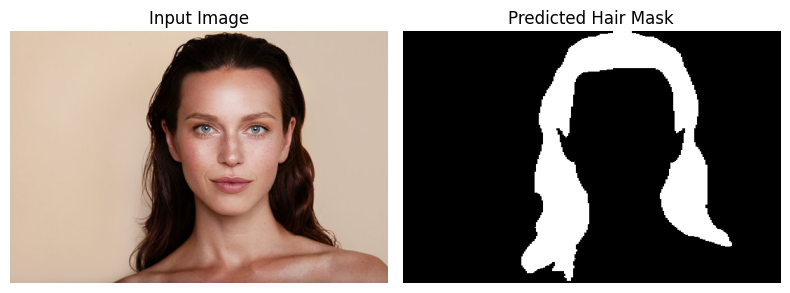

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
with Image.open(INPUT_IMAGE_PATH) as input_image:
    axes[0].imshow(input_image.convert('RGB'))
axes[0].set_title('Input Image')
axes[0].axis('off')
axes[1].imshow(subject_hair_mask, cmap='gray')
axes[1].set_title('Predicted Hair Mask')
axes[1].axis('off')
plt.tight_layout()

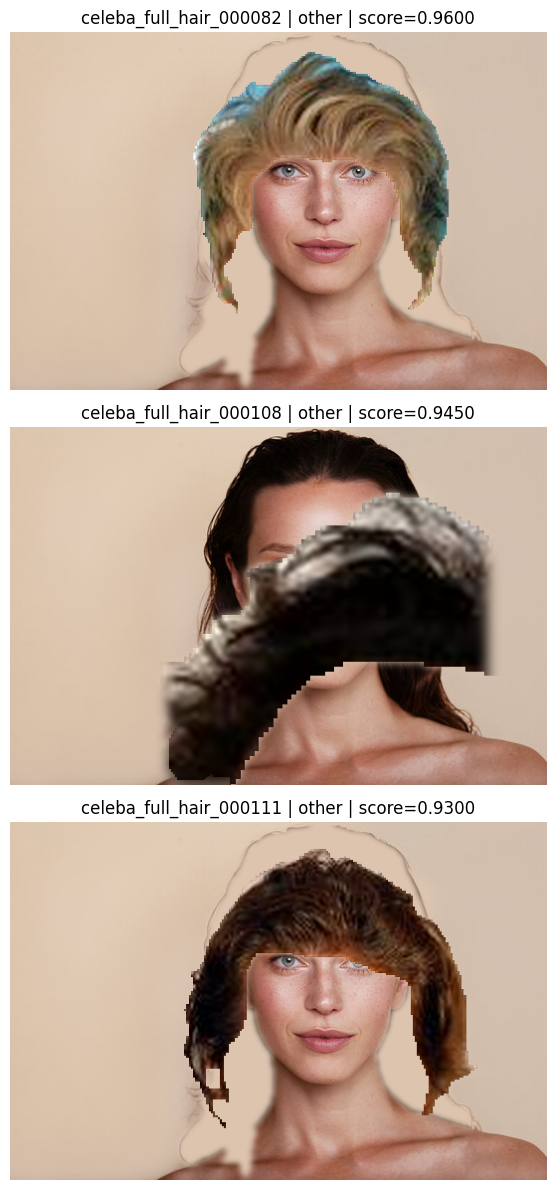

In [10]:
if tryon_rows:
    fig, axes = plt.subplots(len(tryon_rows), 1, figsize=(6, 4 * len(tryon_rows)))
    if len(tryon_rows) == 1:
        axes = [axes]
    for axis, row in zip(axes, tryon_rows):
        with Image.open(row['output_path']) as output_image:
            axis.imshow(output_image.convert('RGB'))
        axis.set_title(f"{row['asset_id']} | {row['style_family']} | score={row['score']:.4f}")
        axis.axis('off')
    plt.tight_layout()
else:
    print('No try-on outputs were created.')

## MediaPipe-First Experimental Renderer

This section keeps the existing notebook flow intact and runs the separate experimental system that uses segmentation only to erase existing hair and MediaPipe landmarks for donor placement.

In [11]:
mediapipe_tryon_rows = []
for item in recommendation_response.recommendations[:TRYON_TOP_K]:
    asset = get_asset_by_id(item.asset_id)
    if asset is None:
        continue
    output_path = render_mediapipe_static_tryon(
        INPUT_IMAGE_PATH,
        analysis,
        asset,
        subject_hair_mask=subject_hair_mask,
    )
    mediapipe_tryon_rows.append(
        {
            'asset_id': item.asset_id,
            'score': item.score,
            'style_family': item.normalized_attributes.style_family,
            'renderer': 'mediapipe_experimental',
            'output_path': output_path,
        }
    )

mediapipe_tryon_df = pd.DataFrame(mediapipe_tryon_rows)
mediapipe_tryon_df

,asset_id,score,style_family,renderer,output_path
0,celeba_full_hair_000082,0.960,other,mediapipe_experimental,D:\Projects\Personal Projects\Hairstyle Recomm...
1,celeba_full_hair_000108,0.945,other,mediapipe_experimental,D:\Projects\Personal Projects\Hairstyle Recomm...
2,celeba_full_hair_000111,0.930,other,mediapipe_experimental,D:\Projects\Personal Projects\Hairstyle Recomm...


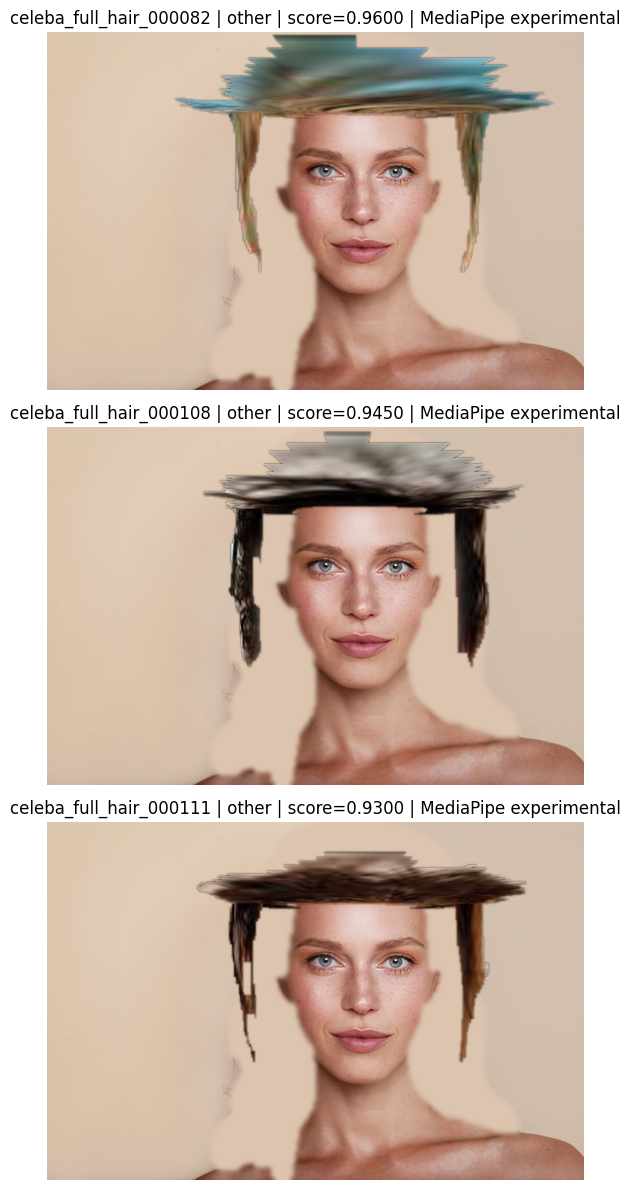

In [12]:
if mediapipe_tryon_rows:
    fig, axes = plt.subplots(len(mediapipe_tryon_rows), 1, figsize=(6, 4 * len(mediapipe_tryon_rows)))
    if len(mediapipe_tryon_rows) == 1:
        axes = [axes]
    for axis, row in zip(axes, mediapipe_tryon_rows):
        with Image.open(row['output_path']) as output_image:
            axis.imshow(output_image.convert('RGB'))
        axis.set_title(f"{row['asset_id']} | {row['style_family']} | score={row['score']:.4f} | MediaPipe experimental")
        axis.axis('off')
    plt.tight_layout()
else:
    print('No MediaPipe experimental outputs were created.')

In [13]:
comparison_df = pd.concat([tryon_df, mediapipe_tryon_df], ignore_index=True)
comparison_df

,asset_id,score,style_family,renderer,output_path
0,celeba_full_hair_000082,0.960,other,default,D:\Projects\Personal Projects\Hairstyle Recomm...
1,celeba_full_hair_000108,0.945,other,default,D:\Projects\Personal Projects\Hairstyle Recomm...
2,celeba_full_hair_000111,0.930,other,default,D:\Projects\Personal Projects\Hairstyle Recomm...
3,celeba_full_hair_000082,0.960,other,mediapipe_experimental,D:\Projects\Personal Projects\Hairstyle Recomm...
4,celeba_full_hair_000108,0.945,other,mediapipe_experimental,D:\Projects\Personal Projects\Hairstyle Recomm...
5,celeba_full_hair_000111,0.930,other,mediapipe_experimental,D:\Projects\Personal Projects\Hairstyle Recomm...
